##### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

##### Load the datasets

In [2]:
ortho_a = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\Orthopaedics_Ward_A_TimeSeries.csv")

In [3]:
ortho_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hospital_id     3655 non-null   object 
 1   datetime        3655 non-null   object 
 2   ward            3655 non-null   object 
 3   occupied_beds   3655 non-null   float64
 4   staffed_beds    3655 non-null   float64
 5   occupancy_rate  3655 non-null   float64
dtypes: float64(3), object(3)
memory usage: 171.5+ KB


- Run the ADF test for every hospital

In [4]:
ortho_a["hospital_id"].unique()

array(['HHN-BIR-01', 'HHN-EDI-01', 'HHN-LON-01', 'HHN-LON-02',
       'HHN-MAN-01'], dtype=object)

In [5]:
results = []

for hospital in ortho_a["hospital_id"].unique():
    hospital_data = (ortho_a[ortho_a["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    adf = adfuller(hospital_data["occupied_beds"])
    results.append({"Hospital": hospital, "ADF Statistic": round(adf[0],4), "p-value": round(adf[1],4), 
                    "Stationary": "Yes" if adf[1] < 0.05 else "No"})

adf_results = pd.DataFrame(results)

print(f"ADF Test Results for Orthopedic Ward A Unit Occupied Beds")
adf_results

ADF Test Results for Orthopedic Ward A Unit Occupied Beds


,Hospital,ADF Statistic,p-value,Stationary
0,HHN-BIR-01,-10.0424,0.0000,Yes
1,HHN-EDI-01,-4.8917,0.0000,Yes
2,HHN-LON-01,-5.2099,0.0000,Yes
3,HHN-LON-02,-3.4247,0.0101,Yes
4,HHN-MAN-01,-3.6789,0.0044,Yes


      All five hospitals showed stable bed occupancy, meaning demand stayed around a normal level over time.
      All hospitals passed the ADF stationarity test, so there was **no long-term trend in bed occupancy.
      Birmingham showed the strongest stability, while London 2 and Manchester showed slightly longer occupancy patterns but were still stable.
      The stable occupancy reflects the planned nature of orthopedic surgeries and predictable patient recovery times.
      Because the data is already stable, no differencing is needed (d = 0)** for forecasting.
      The results support using a **SARIMA/SARIMAX model, with elective surgery schedules included as additional forecasting information to improve prediction accuracy.


- Autocorrelation (ACF) for all hospitals

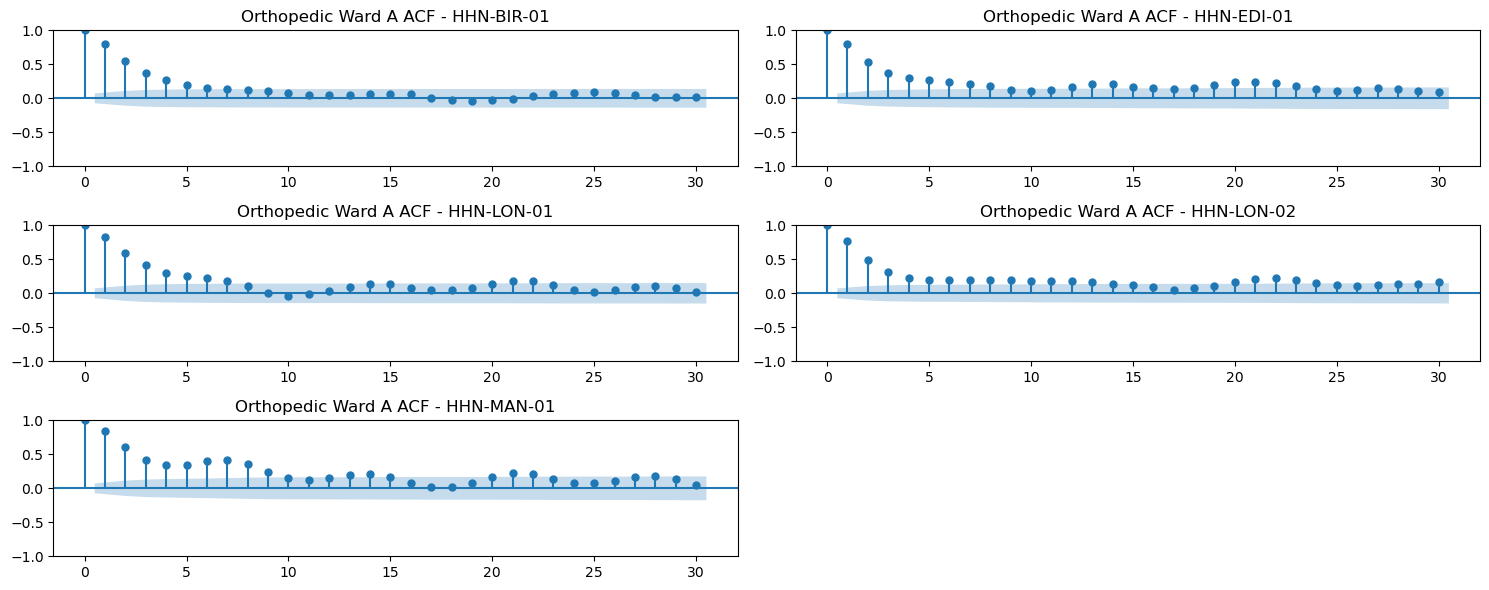

In [6]:
# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

# Loop through hospitals
for i, hospital in enumerate(sorted(ortho_a["hospital_id"].unique())):

    hospital_data = (ortho_a[ortho_a["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_acf(hospital_data["occupied_beds"], lags=30,ax=axes[i])
    axes[i].set_title(f"Orthopedic Ward A ACF - {hospital}")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

     All hospitals showed strong short-term memory, meaning today's bed occupancy is influenced by the previous few days.
     Bed occupancy gradually reduced over time, reflecting the typical 2–4 day recovery period after orthopedic surgery.
     All hospitals showed a clear weekly pattern, with occupancy rising and falling every 7 days due to scheduled elective surgeries.
     The ACF results confirmed that the data is stable, supporting the earlier ADF findings.
     The results support using a SARIMA/SARIMAX model with d = 0 and a 7-day seasonal period to capture both short-term occupancy and weekly surgery schedules.

- PACF for all hospitals

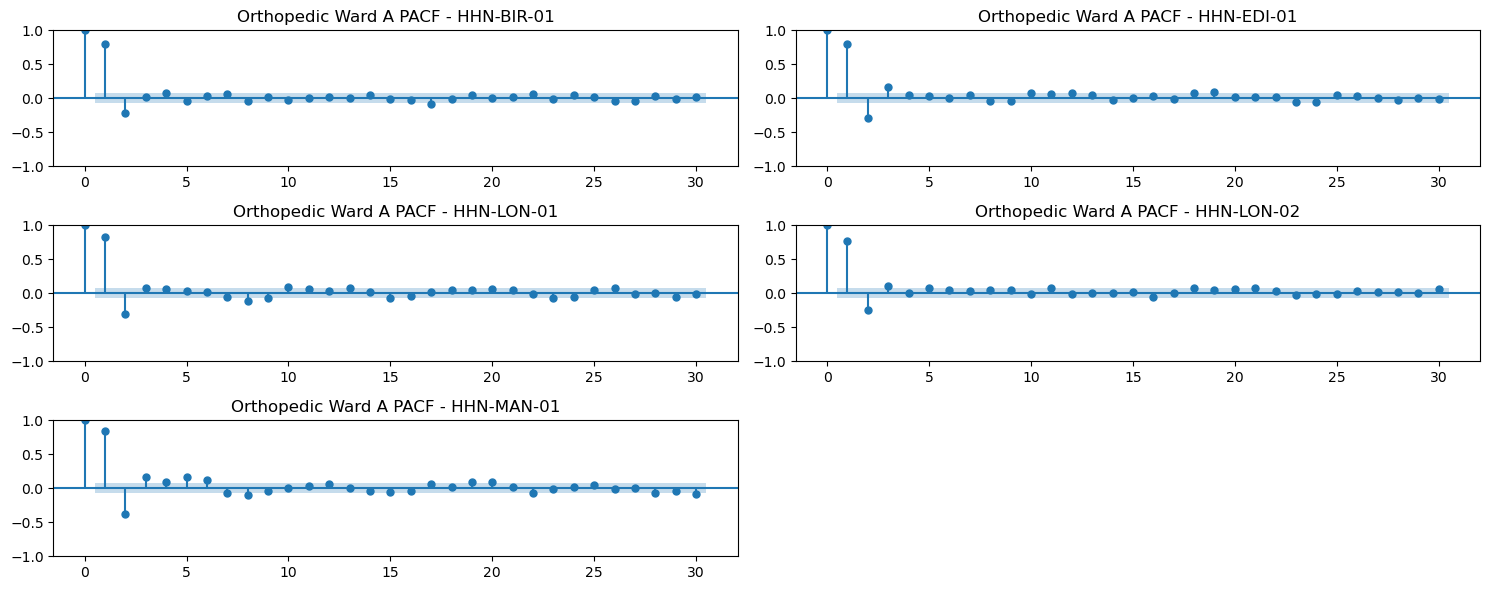

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

for i, hospital in enumerate(sorted(ortho_a["hospital_id"].unique())):

    hospital_data = (ortho_a[ortho_a["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_pacf(hospital_data["occupied_beds"], lags=30, ax=axes[i], method="ywm")
    axes[i].set_title(f"Orthopedic Ward A PACF - {hospital}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

     The PACF plots show that bed occupancy is mainly influenced by the previous 2 days.
     Occupancy stays high from one day to the next, but many patients are discharged within 2–4 days after surgery.
     SARIMA model can be used for all Orthopedic Ward A locations.

- Seasonal Decomposition for all hospitals

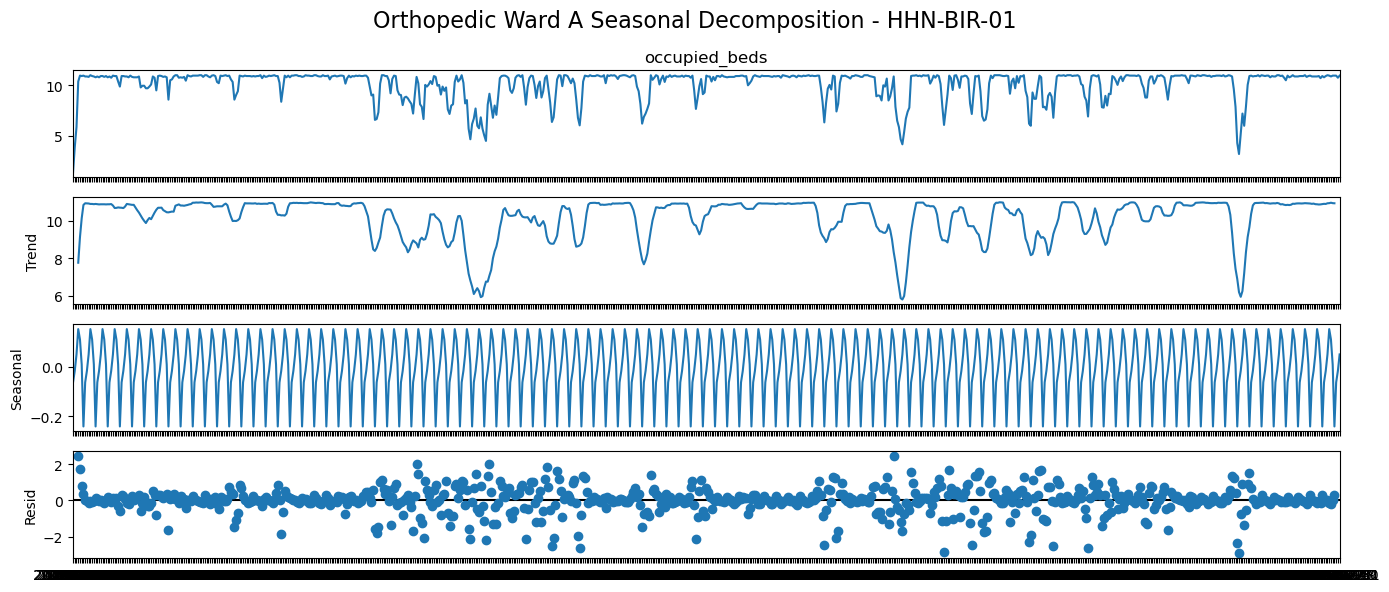

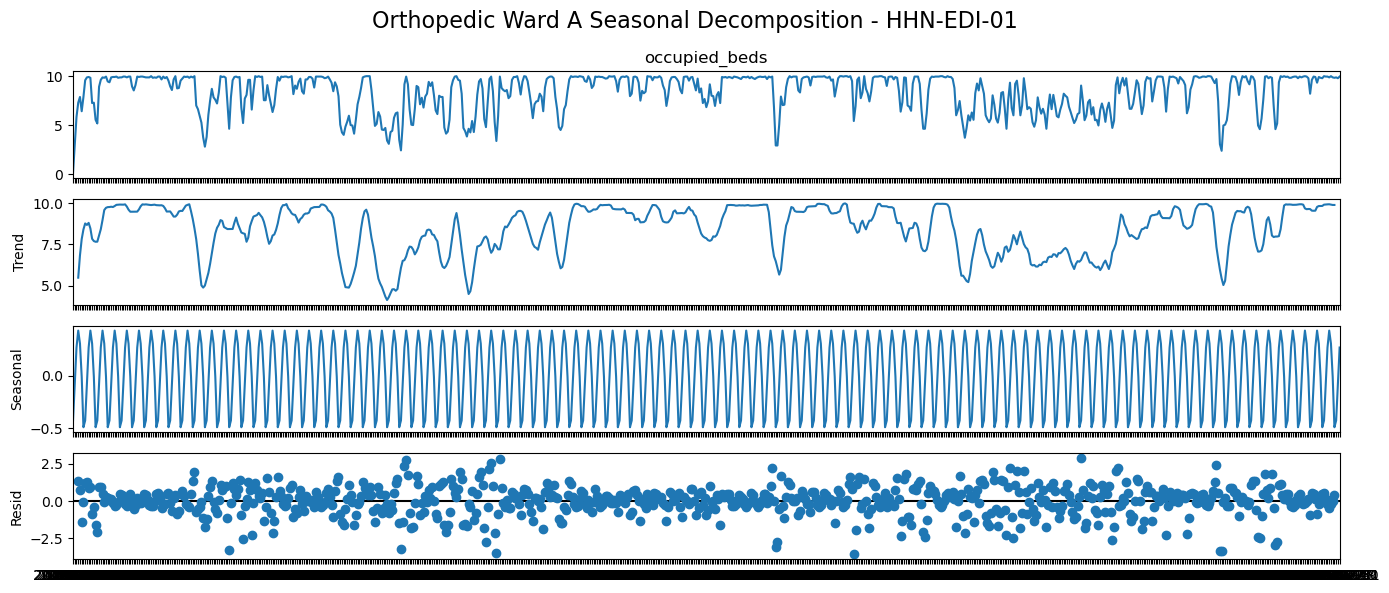

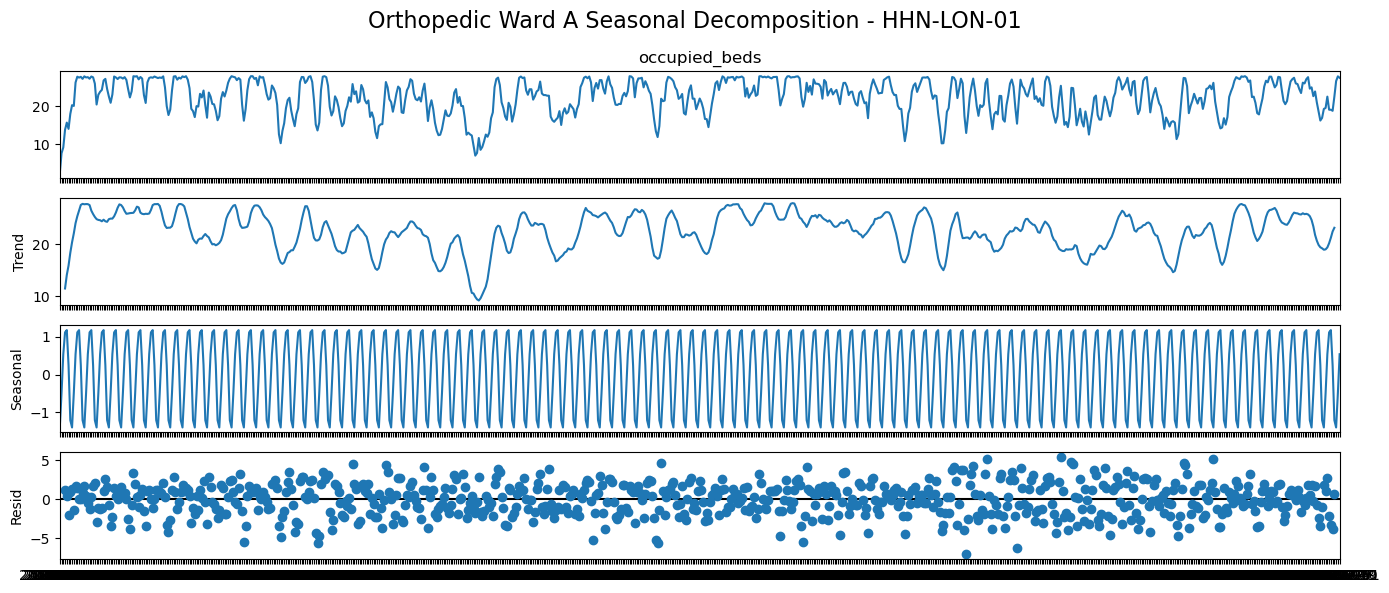

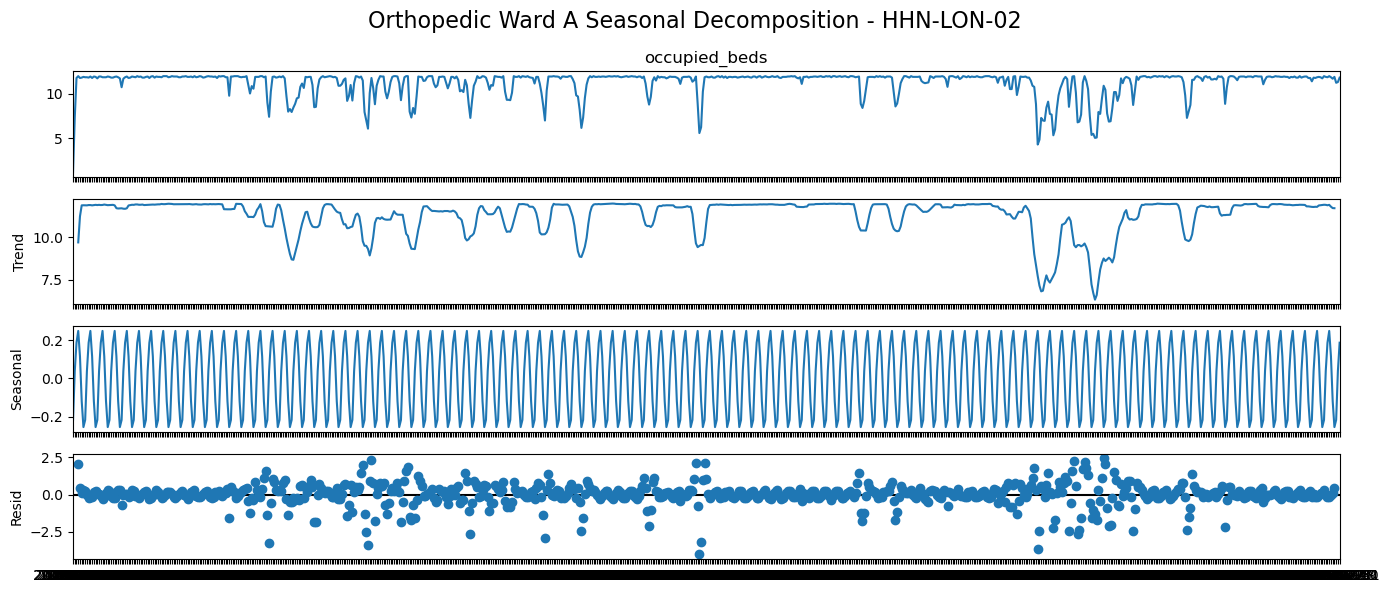

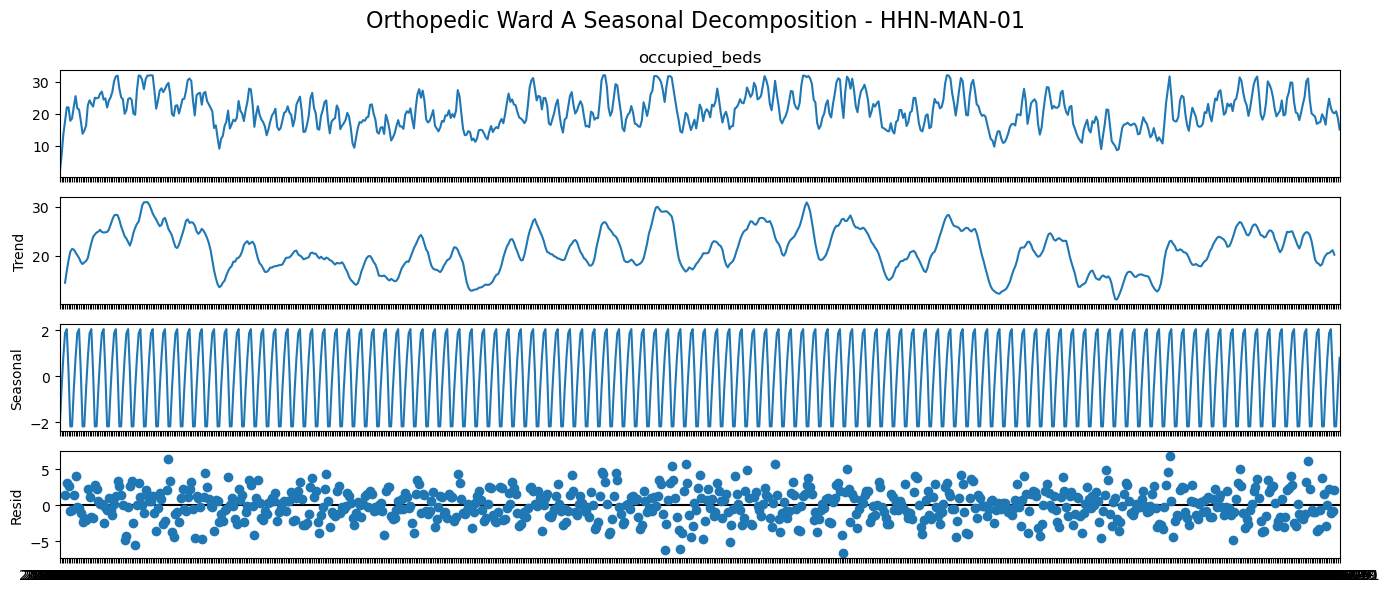

In [8]:
for hospital in sorted(ortho_a["hospital_id"].unique()):

    hospital_data = (ortho_a[ortho_a["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    fig = result.plot()
    fig.set_size_inches(14,6)
    fig.suptitle(f"Orthopedic Ward A Seasonal Decomposition - {hospital}", fontsize=16)
    plt.tight_layout()
    plt.show()

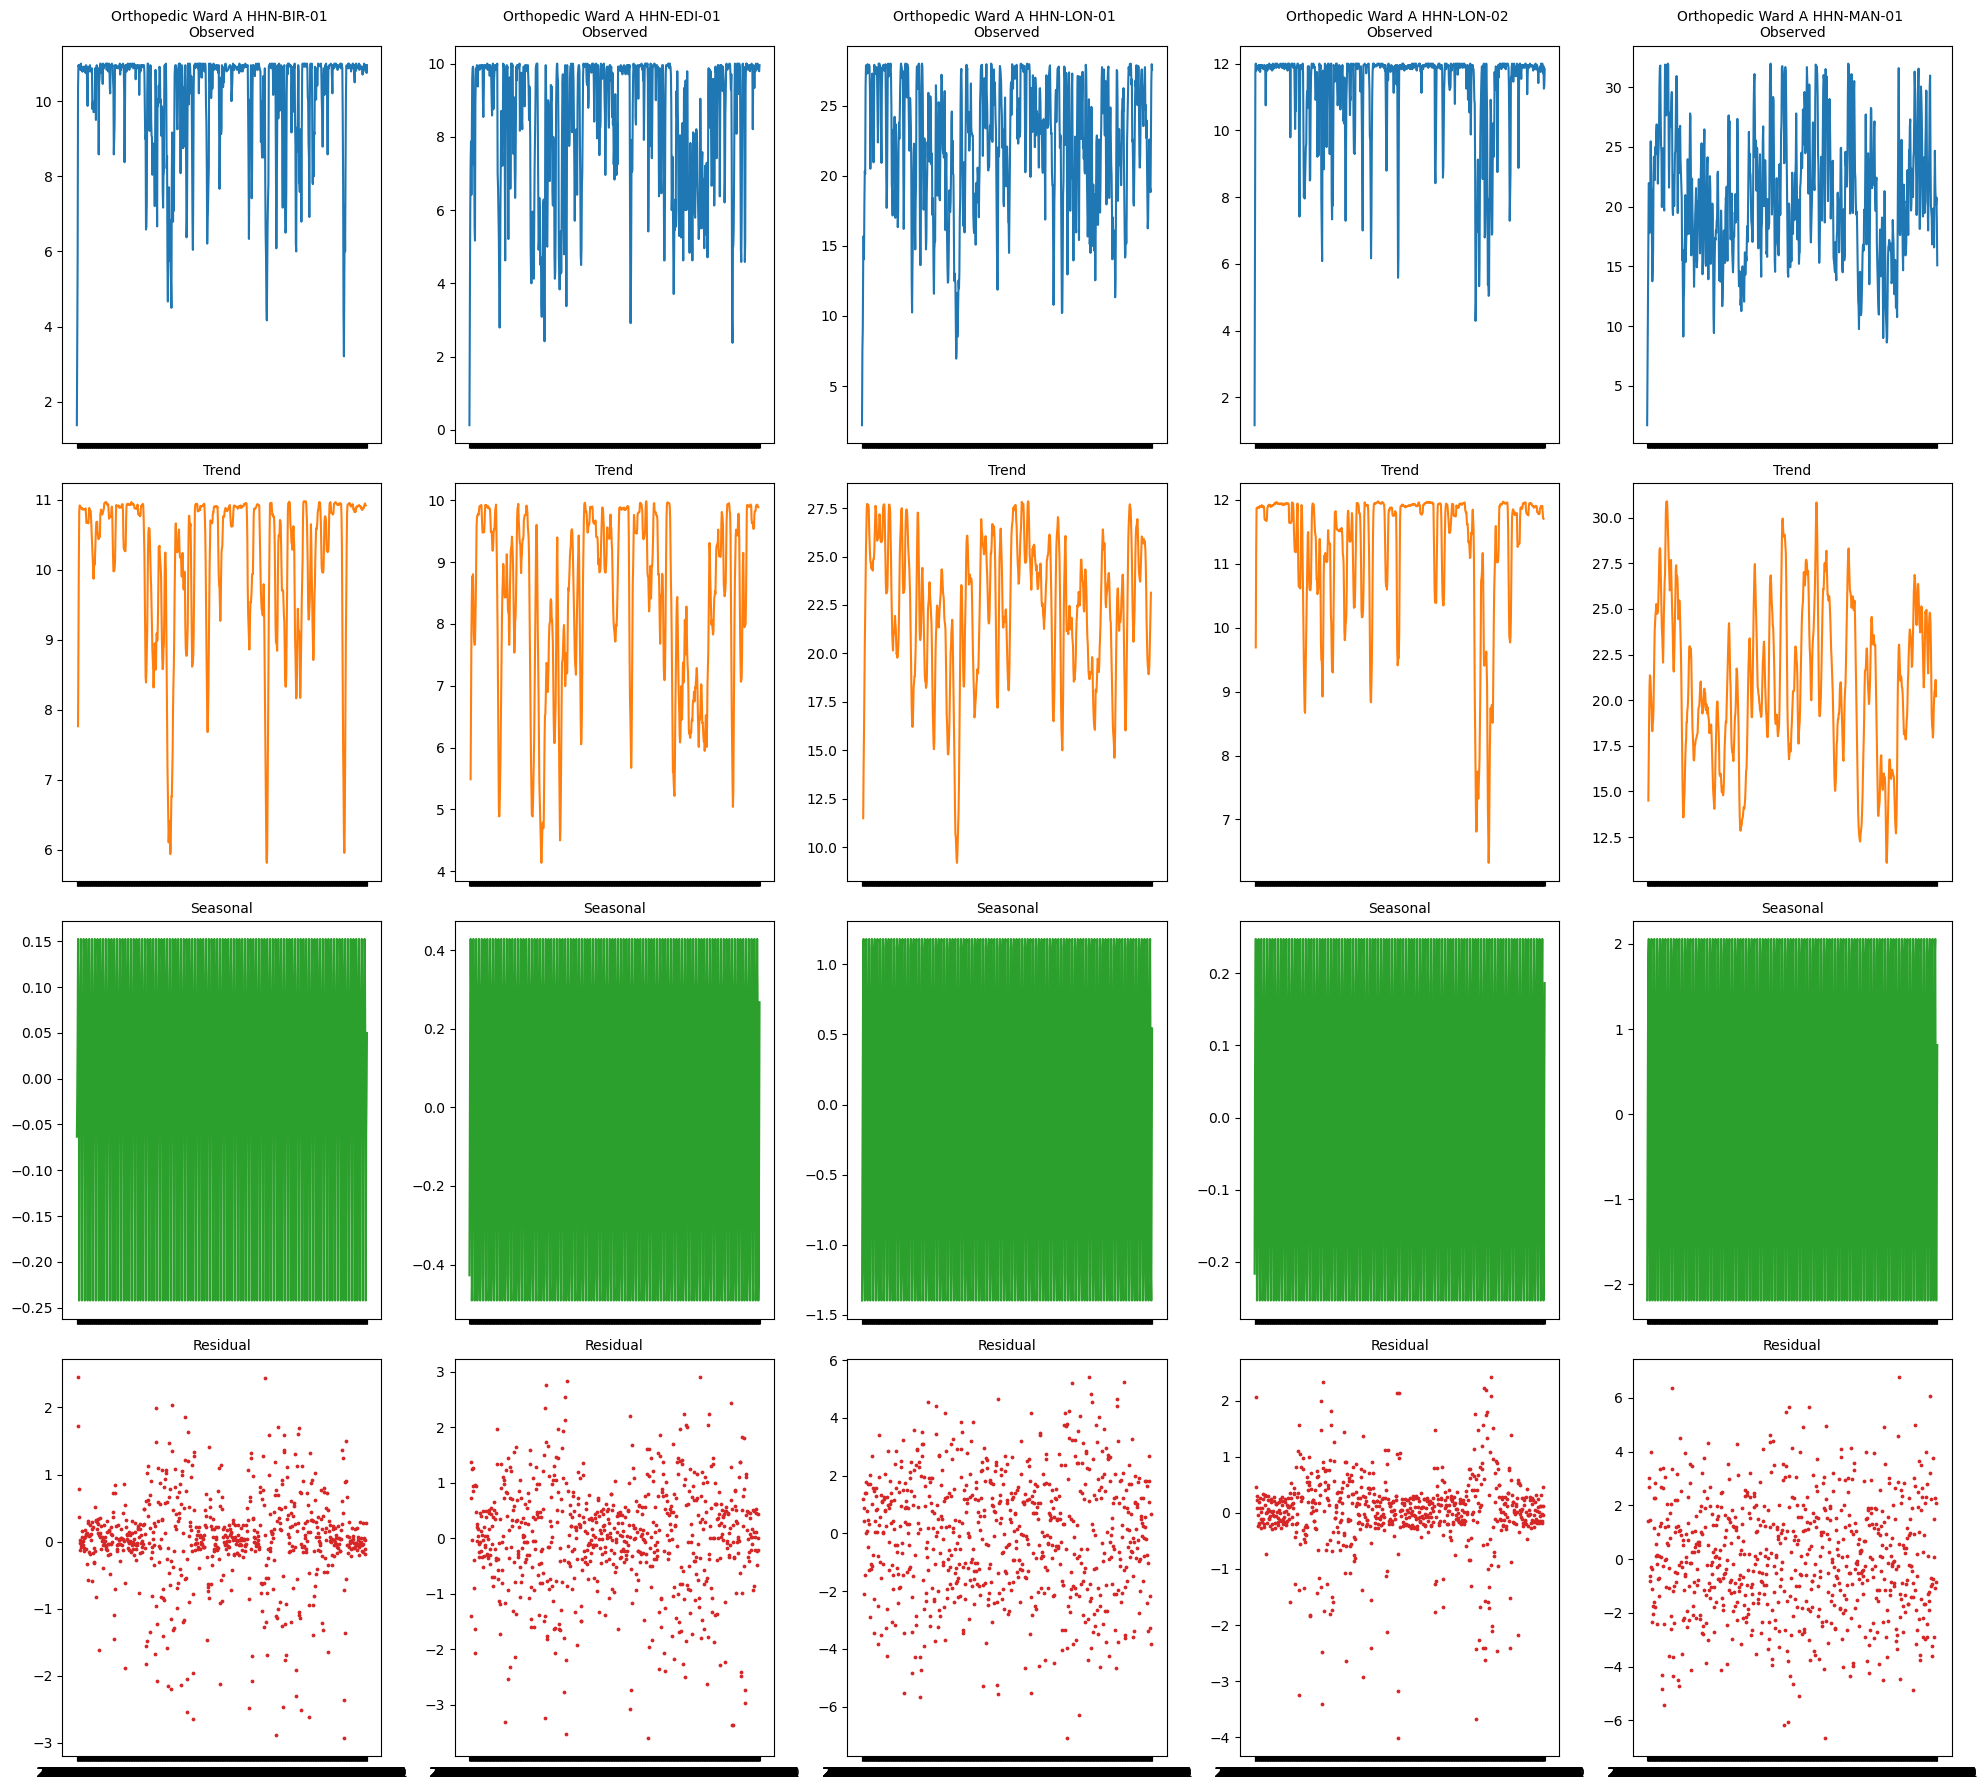

In [9]:
# Create a grid: 4 rows (Observed/Trend/Season/Resid) by X columns (one per hospital)
fig, axes = plt.subplots(4, 5, figsize=(20, 18), sharex=True)

hospitals = sorted(ortho_a["hospital_id"].unique())
for col_idx, hospital in enumerate(hospitals):
    # Filter and decompose data
    hospital_data = ortho_a[ortho_a["hospital_id"] == hospital].sort_values("datetime").set_index("datetime")
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    
    # Manually plot each layer into its specific column cell
    axes[0, col_idx].plot(result.observed, color='tab:blue')
    axes[0, col_idx].set_title(f"Orthopedic Ward A {hospital} \nObserved", fontsize=10)
    
    axes[1, col_idx].plot(result.trend, color='tab:orange')
    axes[1, col_idx].set_title("Trend", fontsize=10)
    
    axes[2, col_idx].plot(result.seasonal, color='tab:green')
    axes[2, col_idx].set_title("Seasonal", fontsize=10)
    
    axes[3, col_idx].scatter(result.resid.index, result.resid, color='tab:red', s=3)
    axes[3, col_idx].set_title("Residual", fontsize=10)

plt.tight_layout()
plt.show()


     Most Orthopedic Ward A units regularly operate at or near full capacity, especially Birmingham, Edinburgh, and London 2, showing limited spare beds.
     London 1 and Manchester have the largest orthopedic wards, while Birmingham, Edinburgh, and London 2 have much smaller capacities.
     The trend changes over time but always returns to a stable level, confirming the ADF test that all hospitals are stationary.
     Bed occupancy follows a clear 7-day cycle, reflecting planned elective surgery schedules and weekend discharges. This weekly effect is strongest in the larger hospitals, especially Manchester and London 1.